In [7]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from sklearn.metrics import mean_squared_error
from train import run_optimized_pipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
test_df, wf_predictions, best_params, fold_model, fold_scaler, features = run_optimized_pipeline(
    file_path="SPY_VIX_daily_clean.parquet",
    n_trials=10,
    n_splits=4
)

1. Prepping Tensor Data for Optuna...
2. The Thunderdome (Running 10 Trials to find Architecture)...
--> Architecture Locked: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3378997883128378, 'lr': 0.007263791452993542}
3. Executing Rolling Window Walk-Forward Validation (4 Eras)...
   -> Inducing Amnesia and Training Era 1/4...
   -> Inducing Amnesia and Training Era 2/4...
   -> Inducing Amnesia and Training Era 3/4...
   -> Inducing Amnesia and Training Era 4/4...


In [9]:
actual_vol = test_df['realized_vol'].values
dates = test_df.index
p10 = wf_predictions[:, 0]
p50 = wf_predictions[:, 1]
p90 = wf_predictions[:, 2]
boardroom_rmse = np.sqrt(mean_squared_error(actual_vol, p50))
print(f"🔥 The Boardroom RMSE: {boardroom_rmse:.4f}")

🔥 The Boardroom RMSE: 0.0121


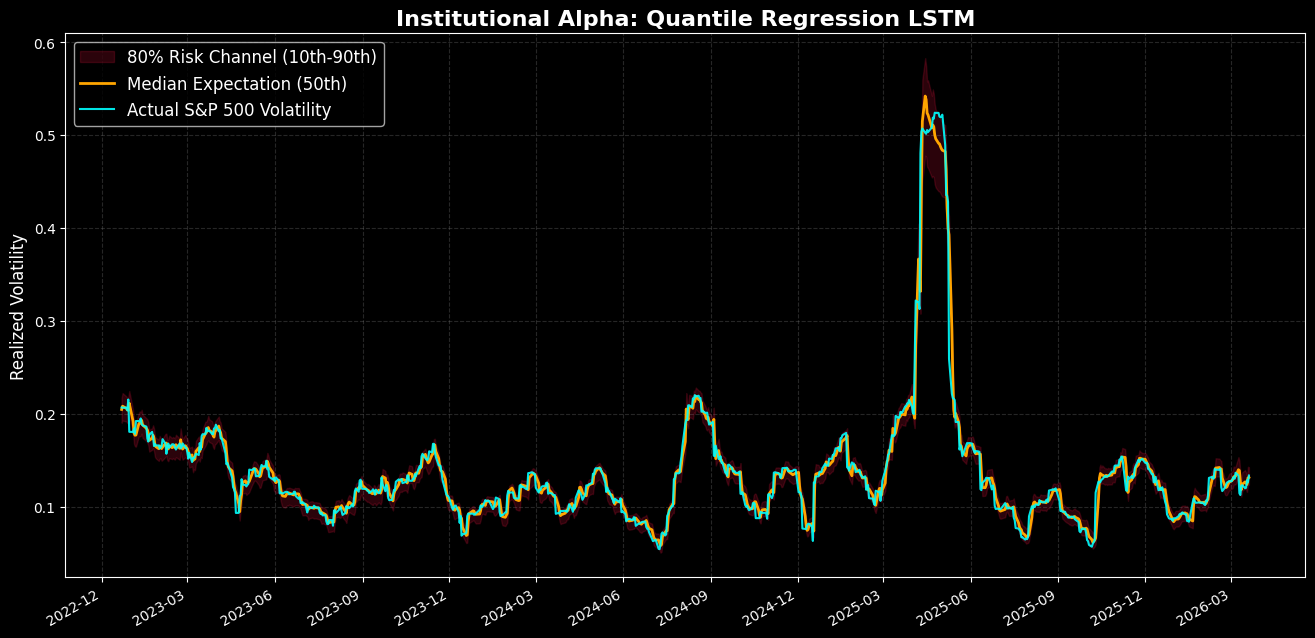

In [10]:
# Paint the canvas
plt.figure(figsize=(16, 8))
plt.style.use('dark_background') # Because light mode is for retail traders

# The Chaos Zone (80% Confidence Interval)
plt.fill_between(dates, p10, p90, color='crimson', alpha=0.2, label='80% Risk Channel (10th-90th)')

# The Median and The Truth
plt.plot(dates, p50, color='orange', linewidth=2, label='Median Expectation (50th)')
plt.plot(dates, actual_vol, color='cyan', linewidth=1.5, alpha=0.9, label='Actual S&P 500 Volatility')

# Formatting
plt.title('Institutional Alpha: Quantile Regression LSTM', fontsize=16, fontweight='bold')
plt.ylabel('Realized Volatility', fontsize=12)
plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.legend(loc='upper left', fontsize=12)

# Make the dates readable
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gcf().autofmt_xdate()

plt.show()

In [11]:
import torch
import numpy as np

# 1. Isolate the final 21 days of reality
# (Assuming your full dataset is still loaded as 'test_df' or 'clean_df')
# We need exactly 1 sequence length of the 3 features
recent_data = test_df[features].tail(21).values

# 2. Translate reality into matrix math using the trained scaler
recent_scaled = fold_scaler.transform(recent_data)

# 3. Reshape it for the LSTM: (Batch=1, Sequence=21, Features=3)
live_tensor = torch.tensor(recent_scaled, dtype=torch.float32).unsqueeze(0)

# 4. Ask the Oracle
fold_model.eval()
with torch.no_grad():
    live_pred_scaled = fold_model(live_tensor).numpy()

# 5. The Exhaust Pipe (Un-scaling the 3 lanes)
dummy_live = np.zeros((1, 3))

# 10th Percentile (Best Case Scenario)
dummy_live[0, 1] = live_pred_scaled[0, 0]
live_10th = fold_scaler.inverse_transform(dummy_live)[0, 1]

# 50th Percentile (The Median Expectation)
dummy_live[0, 1] = live_pred_scaled[0, 1]
live_50th = fold_scaler.inverse_transform(dummy_live)[0, 1]

# 90th Percentile (The Black Swan Boundary)
dummy_live[0, 1] = live_pred_scaled[0, 2]
live_90th = fold_scaler.inverse_transform(dummy_live)[0, 1]

# 6. The Output
print("🔥 TOMORROW'S S&P 500 VOLATILITY FORECAST 🔥")
print("-" * 40)
print(f"🟢 Calm Boundary (10th):  {live_10th:.4f}  ({live_10th * 100:.2f}%)")
print(f"🟡 Median Target (50th):  {live_50th:.4f}  ({live_50th * 100:.2f}%)")
print(f"🔴 Crash Boundary (90th): {live_90th:.4f}  ({live_90th * 100:.2f}%)")

🔥 TOMORROW'S S&P 500 VOLATILITY FORECAST 🔥
----------------------------------------
🟢 Calm Boundary (10th):  0.1306  (13.06%)
🟡 Median Target (50th):  0.1385  (13.85%)
🔴 Crash Boundary (90th): 0.1513  (15.13%)


c:\Users\imich\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [13]:
import yfinance as yf

vix_data = yf.Ticker('^VIX').history(period='1d')['Close']
live_vix = float(vix_data.iloc[-1])
implied_vol = live_vix / 100.0

print("📊 THE VOLATILITY ARBITRAGE DASHBOARD 📊")
print("-" * 55)
print(f"Market's Fear (Live VIX):     {implied_vol:.4f}  ({implied_vol * 100:.2f}%)")
print(f"Model's Median Expectation:   {live_50th:.4f}  ({live_50th * 100:.2f}%)")
print("-" * 55)

if implied_vol > live_90th:
    print("🚨 SIGNAL: SELL VOLATILITY")
    print("Reason: Options are mathematically overpriced. The crowd is panicking.")
    print("Strategy: Iron Condors, Short Straddles. Bleed the retail theta.")
elif implied_vol < live_10th:
    print("🟢 SIGNAL: BUY VOLATILITY")
    print("Reason: Options are mathematically underpriced. The market is asleep.")
    print("Strategy: Long Straddles, Long Puts/Calls. Buy the explosives cheap.")
else:
    print("⚖️ SIGNAL: NO EDGE")
    print("Reason: Market fear perfectly matches our risk channel.")
    print("Strategy: Sit on your hands. We only hunt when the math is broken.")

📊 THE VOLATILITY ARBITRAGE DASHBOARD 📊
-------------------------------------------------------
Market's Fear (Live VIX):     0.2678  (26.78%)
Model's Median Expectation:   0.1385  (13.85%)
-------------------------------------------------------
🚨 SIGNAL: SELL VOLATILITY
Reason: Options are mathematically overpriced. The crowd is panicking.
Strategy: Iron Condors, Short Straddles. Bleed the retail theta.
